# Using this package: assessing which model is best

Using toy data and premade models, this document demonstrates how to assess which modelling approach is best.

In [16]:
from risk_stratifier import (
    run_nested_cv_calibration_assessment,
    validate_binary_y_and_X,
    add_numeric_missingness_indicators,
    make_toy_X_y,
    models
)

Lets get some data ready. There is no need to split into train and test as nested cross-validation is used as default.

In [17]:
toy_X, toy_y = make_toy_X_y()
toy_X_aug = add_numeric_missingness_indicators(toy_X)
toy_X_aug.head(10)

,int_col,float_col,str_col,int_col_missingness,float_col_missingness
0,87,-0.392040,B,present,present
1,6,0.139924,A,present,present
2,39,-0.816575,B,present,present
3,45,-1.146832,C,present,present
4,79,NaN,N,present,missing
5,12,-0.634813,C,present,present
6,43,-1.163474,D,present,present
7,15,0.162060,D,present,present
8,78,0.729716,B,present,present
9,63,-1.587098,B,present,present


check it is permissable

In [18]:
validate_binary_y_and_X(toy_y, toy_X_aug)

X and y data provided for modelling are permissable.


## Prepare logistic lasso, ridge and XGBoost regressions for comparison

In [19]:
cat_cols = ["str_col", "int_col_missingness", "float_col_missingness"]
num_cols = ["int_col", "float_col"]

ridge_pipe, ridge_param = models.get_logistic_ridge_pipeline_and_hyperparameters(cat_cols, num_cols)
lasso_pipe, lasso_param = models.get_logistic_lasso_pipeline_and_hyperparameters(cat_cols, num_cols)
xgb_pipe, xgb_param = models.get_xgboost_pipeline_and_hyperparameters(cat_cols, num_cols)

## `run_nested_cv_calibration_assessment`: a how to?

`run_nested_cv_calibration_assessment` is a function takes provided data and a model pipeline (from sklearn) for binary classification and then runs nested cross-validation (optimizing the brier score). It then outputs results that permit robust assessment of the pipeline's risk stratification performance with a focus on well calibrated probabilities.


    Parameters
    ----------
    pipeline : sklearn Pipeline or estimator
        The sklearn pipeline or estimator to optimize.
    param_distributions : dict
        Dictionary with parameter names as keys and distributions
        or lists of parameters to try.
    X : pd.DataFrame
        Feature matrix.
    y : pd.Series
        Binary target variable (0s and 1s).
    outer_folds : int, default=5
        Number of folds for outer cross-validation loop. 
    outer_repeats : int, default=1
        Number of repeats for outer cross-validation loop.
    inner_folds : int, default=3
        Number of folds for inner loop (hyperparameter tuning).
    inner_repeats : int, default=1
        Number of repeats for inner loop.
    n_iter : int, default=50
        Number of parameter settings sampled in RandomizedSearchCV.
    random_state : int or None, default=None
        Random state for reproducibility.
    n_jobs : int, default=-1
        Number of jobs to run in parallel. -1 uses all processors.
    verbose : bool, default=True
        Whether to print progress information.


    Returns
    -------
    dict
        Dictionary containing:
        - 'outer_scores': DataFrame with metrics per fold
        - 'predictions': DataFrame with true labels and predicted probabilities
        - 'best_params_per_fold': List of best parameters per fold
        - 'summary': Dict with mean and std of each metric
        - 'calibration_plot': A reliability plot

### Assessing the lasso regression in terms of calibration

Lets look at the hyperparamters suggested for the model

In [20]:
lasso_param

{'classifier__C': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]}

There is no point having n_iter > 6 as this exhausts the available distribution

X and y data provided for modelling are permissable.
Fold 1/5 complete: Brier=0.0631, ROC-AUC=0.8847, LogLoss=0.2170
Fold 2/5 complete: Brier=0.0516, ROC-AUC=0.9461, LogLoss=0.1738
Fold 3/5 complete: Brier=0.0729, ROC-AUC=0.8360, LogLoss=0.2524
Fold 4/5 complete: Brier=0.0521, ROC-AUC=0.9216, LogLoss=0.1819
Fold 5/5 complete: Brier=0.0422, ROC-AUC=0.9379, LogLoss=0.1594


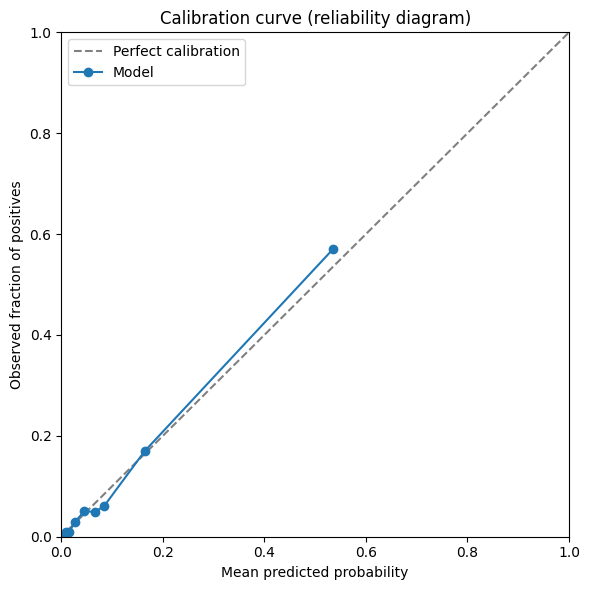

In [21]:
lasso_calibration_results = run_nested_cv_calibration_assessment(
    pipeline= lasso_pipe,
    param_distributions= lasso_param,
    X= toy_X_aug,
    y= toy_y,
    n_iter=6
)

In [22]:
lasso_calibration_results["summary"]

{'brier_score_mean': np.float64(0.0563836238257525),
 'brier_score_std': np.float64(0.011845624273779179),
 'roc_auc_mean': np.float64(0.9052631578947368),
 'roc_auc_std': np.float64(0.04532911250830954),
 'log_loss_mean': np.float64(0.1968760118234216),
 'log_loss_std': np.float64(0.03756459606295499)}

### Assessing the ridge regression in terms of calibration

Looking at the parameter distribution there is little point with n_iter > 6 again

In [23]:
ridge_param

{'classifier__C': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]}

X and y data provided for modelling are permissable.
Fold 1/5 complete: Brier=0.0550, ROC-AUC=0.9296, LogLoss=0.1832
Fold 2/5 complete: Brier=0.0511, ROC-AUC=0.9087, LogLoss=0.1830
Fold 3/5 complete: Brier=0.0477, ROC-AUC=0.9248, LogLoss=0.1703
Fold 4/5 complete: Brier=0.0711, ROC-AUC=0.8533, LogLoss=0.2432
Fold 5/5 complete: Brier=0.0531, ROC-AUC=0.9116, LogLoss=0.1865


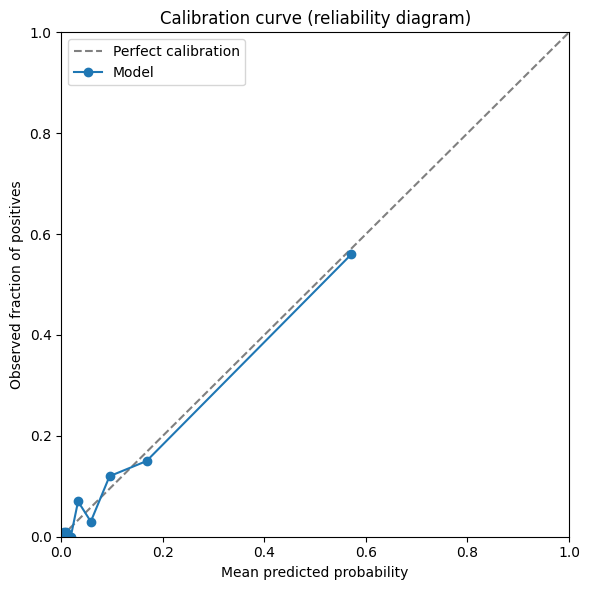

In [24]:
ridge_calibration_results = run_nested_cv_calibration_assessment(
    pipeline= ridge_pipe,
    param_distributions= ridge_param,
    X= toy_X_aug,
    y= toy_y,
    n_iter=6
)

In [25]:
ridge_calibration_results["summary"]

{'brier_score_mean': np.float64(0.05558338017519639),
 'brier_score_std': np.float64(0.009096834475312466),
 'roc_auc_mean': np.float64(0.9056120965396918),
 'roc_auc_std': np.float64(0.030529604293149173),
 'log_loss_mean': np.float64(0.1932178535445614),
 'log_loss_std': np.float64(0.028614836762253324)}

### Assessing XGBoost in terms of calibration

XGBoost has a large permutation of hyperparameters to contend with. for the purposes of demonstration, it is limited to 6.

In [26]:
xgb_param

{'classifier__max_depth': [3, 5, 6, 8],
 'classifier__learning_rate': [0.01, 0.05, 0.1, 0.2],
 'classifier__min_child_weight': [1, 5, 10, 15, 20],
 'classifier__max_delta_step': [0, 1, 2, 4]}

X and y data provided for modelling are permissable.
Fold 1/5 complete: Brier=0.0717, ROC-AUC=0.8360, LogLoss=0.2544
Fold 2/5 complete: Brier=0.0586, ROC-AUC=0.8705, LogLoss=0.2153
Fold 3/5 complete: Brier=0.0598, ROC-AUC=0.8478, LogLoss=0.2247
Fold 4/5 complete: Brier=0.0577, ROC-AUC=0.9020, LogLoss=0.1987
Fold 5/5 complete: Brier=0.0460, ROC-AUC=0.9514, LogLoss=0.1617


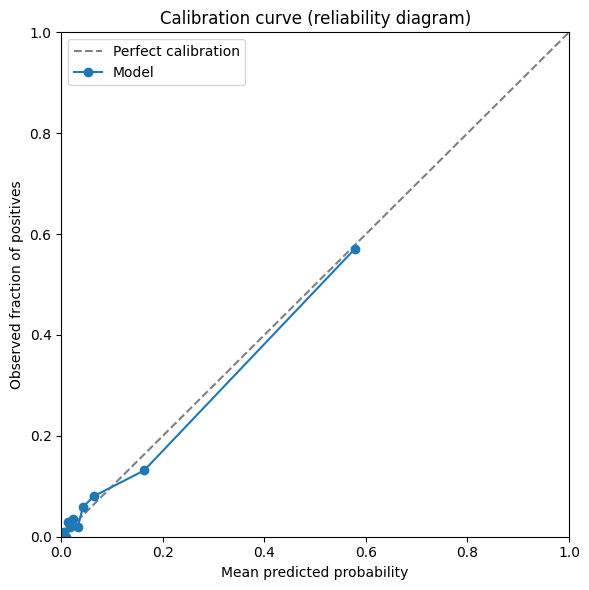

In [27]:
xgb_calibration_results = run_nested_cv_calibration_assessment(
    pipeline= xgb_pipe,
    param_distributions= xgb_param,
    X= toy_X_aug,
    y= toy_y,
    n_iter=6
)

In [28]:
xgb_calibration_results["summary"]

{'brier_score_mean': np.float64(0.05875483527779579),
 'brier_score_std': np.float64(0.009120145461480867),
 'roc_auc_mean': np.float64(0.8815353300378016),
 'roc_auc_std': np.float64(0.04648030969917753),
 'log_loss_mean': np.float64(0.210948194540049),
 'log_loss_std': np.float64(0.0341739066007087)}

The underlying associations are so simple in this toy version that all models are pretty comparable. However, when used in force, significant variations can be seen.